In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

# Đọc dataset từ Google Drive
path = '/content/drive/MyDrive/Colab Notebooks/data4/online_retail_II.xlsx'
df_raw = pd.read_excel(path)

# Tạo bản copy để xử lý dữ liệu
df = df_raw.copy()

print("Kích thước dữ liệu:", df.shape)

Kích thước dữ liệu: (525461, 8)


1. Data Collection

Nhóm sử dụng bộ dữ liệu Online Retail Dataset được tải từ Kaggle. Dataset này ghi lại các giao dịch bán lẻ trực tuyến của một doanh nghiệp trong giai đoạn 2009–2011, bao gồm các thông tin như mã hóa đơn (Invoice), mã sản phẩm (Stock Code), mô tả sản phẩm (Description), số lượng (Quantity), ngày giao dịch (InvoiceDate), giá bán (Price), mã khách hàng (Customer ID) và quốc gia (Country).            

Ngay khi tải dữ liệu về và thực hiện bước đọc dữ liệu vào môi trường phân tích bằng Python (Pandas), nhóm nhận thấy rằng dataset có quy mô khá lớn và chứa nhiều thông tin hữu ích. Tuy nhiên, giống như phần lớn dữ liệu thực tế trong kinh doanh, dữ liệu này chưa thể sử dụng ngay cho phân tích. Dataset vẫn tồn tại nhiều vấn đề phổ biến của dữ liệu thô (raw data) như:
- Giá trị thiếu (missing values)
- Khả năng xuất hiện dữ liệu trùng lặp
- Sai định dạng kiểu dữ liệu
- Các giao dịch bất thường hoặc không hợp lệ
- Các giá trị cực đoan (outliers)

Do đó, trước khi tiến hành phân tích dữ liệu (EDA) hay xây dựng insight, nhóm cần thực hiện một bước quan trọng: Data Cleaning.


In [3]:
# Xem 5 dòng đầu của dataset
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
# Kiểm tra cấu trúc dữ liệu và kiểu dữ liệu
df.info()

# Thống kê các biến số trong dataset
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


2. Khám phá dữ liệu ban đầu (Initial Data Exploration)

Trước khi xử lý dữ liệu, nhóm tiến hành khám phá dataset để hiểu rõ cấu trúc và đặc điểm của dữ liệu. Các hàm như:

- head() để quan sát những dòng dữ liệu đầu tiên
- info() để kiểm tra kiểu dữ liệu và số lượng giá trị thiếu
- describe() để xem các thống kê mô tả cơ bản

được sử dụng trong bước này.

Thông qua quá trình quan sát ban đầu, nhóm nhận thấy một số điểm đáng chú ý:

- Dataset có nhiều cột thông tin khác nhau liên quan đến giao dịch bán hàng.
- Một số cột chứa missing values, đặc biệt là cột Customer ID.
- Một số biến số có thể chứa giá trị bất thường, ví dụ như số lượng sản phẩm (Quantity) hoặc giá bán (Price).
- Một số biến cần được chuẩn hóa kiểu dữ liệu để phục vụ phân tích sau này.

Việc dành thời gian khám phá dữ liệu ở bước đầu giúp nhóm hiểu rõ bản chất của dataset trước khi can thiệp vào dữ liệu, từ đó tránh các quyết định xử lý mang tính cảm tính. Đây là một bước quan trọng trong quy trình phân tích dữ liệu, vì các quyết định cleaning ở giai đoạn này sẽ ảnh hưởng trực tiếp đến kết quả phân tích phía sau.


In [5]:
# Kiểm tra tên cột và kiểu dữ liệu
print ("Danh sách các cột:")
print(df.columns)

print("kiểu dữ liệu:")
print(df.dtypes)


Danh sách các cột:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')
kiểu dữ liệu:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


3. Kiểm tra tính nhất quán của dữ liệu (Data Consistency)

Trong quá trình khám phá dữ liệu ban đầu, nhóm cũng tiến hành kiểm tra tính nhất quán của dataset bằng cách quan sát tên cột và kiểu dữ liệu của từng biến.

Việc kiểm tra này giúp đảm bảo rằng:

- Các cột dữ liệu được lưu trữ đồng nhất
- Không tồn tại sự khác biệt về cấu trúc dữ liệu
- Các biến được định dạng phù hợp cho các bước phân tích tiếp theo

Kết quả kiểm tra cho thấy dataset có cấu trúc ổn định và các cột dữ liệu được tổ chức nhất quán, giúp quá trình cleaning và phân tích được thực hiện thuận lợi hơn.

In [6]:
# Kiểm tra số lượng missing values
missing = df.isnull().sum()

print("Số lượng giá trị thiếu:")
print(missing)

Số lượng giá trị thiếu:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [7]:
# Xóa các dòng không có Customer ID
before_shape = df.shape

df = df.dropna(subset=['Customer ID'])

after_shape = df.shape

print("Trước khi xóa:", before_shape)
print("Sau khi xóa:", after_shape)

Trước khi xóa: (525461, 8)
Sau khi xóa: (417534, 8)


In [8]:
# Kiểm tra lại dữ liệu thiếu sau khi xử lý
print("Missing sau xử lý:")
print(df.isnull().sum())

Missing sau xử lý:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


4. Xử lý giá trị thiếu (Missing Values)

Sau khi kiểm tra chi tiết bằng phương thức isnull().sum(), nhóm nhận thấy cột Customer ID có một lượng giá trị thiếu tương đối lớn.

Đây là một vấn đề quan trọng vì các phân tích phía sau của bài toán – đặc biệt là phân tích hành vi khách hàng – đều phụ thuộc vào việc xác định chính xác từng khách hàng. Nếu một giao dịch không có Customer ID, giao dịch đó sẽ không thể liên kết với bất kỳ khách hàng nào.

Ban đầu, nhóm đã cân nhắc việc imputation (điền giá trị thiếu) để giữ lại càng nhiều dữ liệu càng tốt. Tuy nhiên, khi xem xét bản chất của biến Customer ID, nhóm nhận ra rằng đây không phải là một biến có thể suy luận từ các biến khác, mà là một mã định danh duy nhất cho mỗi khách hàng.

Việc điền giá trị giả định cho biến này sẽ dẫn đến hai vấn đề:

- Có thể gán nhầm nhiều giao dịch vào cùng một khách hàng không tồn tại.
- Làm sai lệch các phân tích về hành vi khách hàng như tần suất mua hàng hoặc tổng giá trị mua.

Do đó, nhóm quyết định loại bỏ các dòng dữ liệu không có Customer ID. Mặc dù quyết định này làm giảm số lượng quan sát của dataset, nhưng đổi lại giúp đảm bảo rằng mọi giao dịch còn lại đều có thể liên kết với một khách hàng cụ thể, điều rất quan trọng cho các phân tích tiếp theo.


In [9]:
# Kiểm tra duplicated
dup = df.duplicated().sum()

print("Số dòng trùng:", dup)

if dup > 0:
  df = df.drop_duplicates()
  print("Đã xóa duplicate")
else:
  print("Không có duplicate nên không cần xử lý")

Số dòng trùng: 6771
Đã xóa duplicate


In [10]:
# Invoice bắt đầu bằng 'C' là đơn bị hủy
cancel = df['Invoice'].astype(str).str.startswith('C').sum()

print("Số đơn bị hủy:", cancel)

Số đơn bị hủy: 9816


In [11]:
# Xem dữ liệu các đơn bị hủy
fix = df[df['Invoice'].astype(str).str.startswith('C')]

print("Số dòng đơn bị hủy:", fix.shape)
fix.head()

Số dòng đơn bị hủy: (9816, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


5. Xác định và loại bỏ giao dịch bị hủy

Trong quá trình khám phá dữ liệu, nhóm phát hiện rằng một số mã hóa đơn trong cột Invoice bắt đầu bằng ký tự “C”.

Sau khi tìm hiểu tài liệu mô tả dataset, nhóm nhận ra rằng các hóa đơn này đại diện cho các giao dịch bị hủy (cancel transactions).

Nếu giữ lại những dòng dữ liệu này, các phân tích về doanh thu sẽ bị sai lệch vì:

- Những giao dịch này không tạo ra doanh thu thực tế
- Chúng có thể khiến việc tính toán doanh thu và tần suất mua hàng trở nên không chính xác

Vì vậy, nhóm quyết định loại bỏ toàn bộ các giao dịch bị hủy để đảm bảo dataset chỉ bao gồm các giao dịch mua hàng thực sự.


In [12]:
# Kiểm tra các giá trị không hợp lệ
invalid_qty = (df['Quantity'] <= 0).sum()
invalid_price = (df['Price'] <= 0).sum()

print("Quantity không hợp lệ:", invalid_qty)
print("Price không hợp lệ:", invalid_price)

Quantity không hợp lệ: 9816
Price không hợp lệ: 31


In [13]:
# Loại bỏ các dòng có Quantity <= 0 hoặc Price <= 0
df = df[(df['Quantity'] > 0)]
df = df[(df['Price'] > 0)]

print("Sau xử lý:")
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("Price <= 0:", (df['Price'] <= 0).sum())

Sau xử lý:
Quantity <= 0: 0
Price <= 0: 0


6. Xử lý dữ liệu không hợp lệ (Invalid Values)

Trong bước tiếp theo, nhóm kiểm tra các giá trị bất thường ở hai biến quan trọng:

- Quantity (số lượng sản phẩm)
- Price (giá bán)

Kết quả kiểm tra cho thấy tồn tại một số giá trị nhỏ hơn hoặc bằng 0.

Ban đầu, nhóm đã cân nhắc khả năng rằng các giá trị âm có thể phản ánh các trường hợp trả hàng (returns). Tuy nhiên, vì dataset đã loại bỏ các giao dịch bị hủy trước đó và mục tiêu của bài toán là phân tích hành vi mua và doanh thu, việc giữ lại các giá trị này có thể làm nhiễu kết quả phân tích.

Do đó, nhóm quyết định chỉ giữ lại các giao dịch có Quantity > 0 và Price > 0. Điều này giúp đảm bảo rằng dataset chỉ bao gồm các giao dịch bán hàng hợp lệ và có ý nghĩa kinh tế.


In [14]:
# Chuyển InvoiceDate sang dạng datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df.dtypes)

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [15]:
# Tạo biến doanh thu
df['Revenue'] = df['Quantity'] * df['Price']

df[['Quantity', 'Price', 'Revenue']].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


7. Tạo biến Revenue

Dataset ban đầu không chứa biến thể hiện doanh thu của từng giao dịch.

Để thuận tiện cho việc phân tích, nhóm tạo thêm biến Revenue theo công thức:

Revenue = Quantity × Price

Việc tạo biến này giúp:

- Đơn giản hóa các phép tính trong các bước phân tích sau
- Đảm bảo rằng toàn bộ nhóm sử dụng cùng một định nghĩa về doanh thu
- Giảm nguy cơ sai lệch khi tính toán ở các bước sau


In [16]:
# Tách Year và Month từ InvoiceDate
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month

df[['InvoiceDate', 'Year', 'Month']].head()

,InvoiceDate,Year,Month
0,2009-12-01 07:45:00,2009,12
1,2009-12-01 07:45:00,2009,12
2,2009-12-01 07:45:00,2009,12
3,2009-12-01 07:45:00,2009,12
4,2009-12-01 07:45:00,2009,12



8. Chuẩn hóa kiểu dữ liệu (Data Type Standardization)

Một vấn đề khác được phát hiện là cột InvoiceDate ban đầu được lưu dưới dạng chuỗi (string). Điều này gây khó khăn khi thực hiện các phân tích theo thời gian như:

- Phân tích theo tháng
- Phân tích theo năm
- Phân tích xu hướng doanh thu theo thời gian

Vì vậy, nhóm đã chuyển cột này sang kiểu dữ liệu datetime bằng phương thức pd.to_datetime().

Sau khi chuẩn hóa kiểu dữ liệu, nhóm có thể dễ dàng trích xuất các thông tin thời gian như Year và Month, phục vụ cho các bước phân tích xu hướng sau này.


In [17]:
# Kiểm tra các biến định danh trong dataset
print("Số lượng Invoice:", df['Invoice'].nunique())
print("Số lượng Customer ID:", df['Customer ID'].nunique())
print("Số lượng StockCode:", df['StockCode'].nunique())


Số lượng Invoice: 19213
Số lượng Customer ID: 4312
Số lượng StockCode: 4017


9. Xác định mối quan hệ dữ liệu (Data Relationship)

Ngoài việc làm sạch dữ liệu, nhóm cũng xác định các biến đóng vai trò định danh trong dataset nhằm phục vụ cho việc phân tích và liên kết dữ liệu.

Cụ thể:

- Invoice được sử dụng để định danh từng hóa đơn giao dịch
- Customer ID được sử dụng để xác định từng khách hàng
- StockCode đại diện cho từng sản phẩm

Việc kiểm tra các biến định danh giúp nhóm hiểu rõ mối quan hệ giữa khách hàng, sản phẩm và giao dịch trong dataset. Đồng thời, bước này cũng hỗ trợ đảm bảo dữ liệu có thể được tích hợp hoặc mở rộng dễ dàng trong các phân tích tiếp theo.

In [18]:
# Xử lý Outliers bằng phương pháp IQR

print("Thống kế trước khi xử lý:")
print(df['Quantity'].describe())

Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Quantity'] >= lower_bound) & (df['Quantity'] <= upper_bound)]

print("Thống kê sau khi xử lý:")
print(df['Quantity'].describe())

Thống kế trước khi xử lý:
count    400916.000000
mean         13.767418
std          97.638385
min           1.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       19152.000000
Name: Quantity, dtype: float64
Thống kê sau khi xử lý:
count    374622.000000
mean          6.821273
std           6.525594
min           1.000000
25%           2.000000
50%           4.000000
75%          12.000000
max          27.000000
Name: Quantity, dtype: float64


10. Xử lý Outliers

Sau khi hoàn thành các bước cleaning cơ bản, nhóm tiến hành kiểm tra phân phối dữ liệu của biến Quantity và nhận thấy tồn tại một số giá trị cực lớn so với phần còn lại của dataset.

Các giá trị này có thể là:

- Các đơn hàng số lượng rất lớn
- Hoặc các giá trị nhập sai

Nếu giữ lại những giá trị cực đoan này, các chỉ số thống kê như mean có thể bị kéo lệch, khiến dữ liệu không còn đại diện cho hành vi mua hàng phổ biến của khách hàng.

Sau khi cân nhắc, nhóm quyết định xử lý outliers bằng phương pháp IQR (Interquartile Range).

Phương pháp này xác định ngưỡng:
- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Các giá trị nằm ngoài khoảng này được xem là outliers và được loại bỏ khỏi dataset.

Nhóm lựa chọn IQR thay vì Z-score vì:

- Dữ liệu không có dấu hiệu tuân theo phân phối chuẩn
- IQR ổn định hơn và ít bị ảnh hưởng bởi các giá trị cực đoan

Sau khi áp dụng phương pháp này, dataset trở nên ổn định và đại diện hơn cho hành vi mua hàng điển hình.


11. Một vấn đề phát sinh trong quá trình xử lý dữ liệu

Trong quá trình làm việc với dataset, nhóm gặp một vấn đề thú vị liên quan đến việc chạy lại notebook nhiều lần.

Ở lần chạy đầu tiên, kết quả của các bước kiểm tra dữ liệu (ví dụ số lượng giá trị không hợp lệ) hoàn toàn hợp lý. Tuy nhiên, khi chạy lại toàn bộ notebook, một số kết quả thống kê lại thay đổi so với ban đầu.

Sau khi kiểm tra lại pipeline xử lý dữ liệu, nhóm nhận ra nguyên nhân là do dataset đã bị thay đổi sau khi các bước cleaning được thực hiện. Khi chạy lại các bước kiểm tra trên dataset đã được xử lý trước đó, các giá trị không hợp lệ đã bị loại bỏ nên kết quả kiểm tra trở thành 0.

Để khắc phục vấn đề này, nhóm đã điều chỉnh lại notebook theo hướng:

- Luôn đọc lại dữ liệu gốc (raw dataset) ngay từ đầu notebook
- Đảm bảo rằng mọi bước cleaning đều được thực hiện theo đúng thứ tự
- Không sử dụng lại dataset đã bị biến đổi từ lần chạy trước

Cách tiếp cận này giúp notebook trở nên reproducible, nghĩa là mỗi lần chạy lại toàn bộ pipeline đều cho ra kết quả nhất quán.


12. Data Integration và Tự động hóa xử lý dữ liệu

Vì dataset được cung cấp dưới dạng một bảng dữ liệu hoàn chỉnh nên nhóm không cần thực hiện việc hợp nhất nhiều file dữ liệu khác nhau bằng pd.concat() hoặc pd.merge().

Tuy nhiên, nhóm vẫn thực hiện kiểm tra:

- tính nhất quán của cấu trúc dữ liệu,
- các biến định danh
- mối quan hệ giữa các thành phần dữ liệu

nhằm đảm bảo dataset sẵn sàng cho việc tích hợp hoặc mở rộng trong tương lai.

Toàn bộ quá trình xử lý dữ liệu được thực hiện bằng Python và Pandas thay vì thao tác thủ công, giúp:

- giảm nguy cơ sai sót,
- đảm bảo tính nhất quán
- tăng khả năng tái lập của quy trình phân tích dữ liệu.

In [19]:
# Lưu dataset đã làm sạch
output_path = '/content/drive/MyDrive/Colab Notebooks/data4/online_retail_II_clean.xlsx'
df.to_excel(output_path, index=False)

print("Đã lưu file tại:", output_path)

Đã lưu file tại: /content/drive/MyDrive/Colab Notebooks/data4/online_retail_II_clean.xlsx


13. Kết quả sau khi làm sạch dữ liệu

Sau khi hoàn thành toàn bộ quy trình cleaning, dataset đã thay đổi đáng kể so với dữ liệu ban đầu:

- Các dòng thiếu Customer ID đã được loại bỏ
- Các giao dịch bị hủy không còn xuất hiện
- Các giá trị không hợp lệ của Quantity và Price đã được xử lý
- Kiểu dữ liệu thời gian đã được chuẩn hóa
- Biến Revenue đã được bổ sung
- Các outliers đã được loại bỏ

Nhờ quá trình này, dataset không chỉ trở nên sạch hơn về mặt kỹ thuật, mà còn phù hợp hơn với mục tiêu phân tích hành vi khách hàng và doanh thu.

14. Lưu dữ liệu đã làm sạch

Sau khi hoàn tất toàn bộ quá trình xử lý, dataset đã được lưu lại thành một file mới:

clean_data.xlsx

File này đóng vai trò là refined dataset, được sử dụng làm đầu vào cho các bước tiếp theo của dự án như:

- Exploratory Data Analysis (EDA)
- Visualization
- Customer behavior analysis
- Insight extraction

Việc tách riêng dữ liệu gốc (raw data) và dữ liệu đã làm sạch (clean data) giúp đảm bảo tính minh bạch và khả năng tái lập của toàn bộ quá trình phân tích.


In [20]:
# Kiểm tra dataset cuối
print("Kích thước cuối:", df.shape)
df.info()
df.describe()

Kích thước cuối: (374622, 11)
<class 'pandas.core.frame.DataFrame'>
Index: 374622 entries, 0 to 525460
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      374622 non-null  object        
 1   StockCode    374622 non-null  object        
 2   Description  374622 non-null  object        
 3   Quantity     374622 non-null  int64         
 4   InvoiceDate  374622 non-null  datetime64[ns]
 5   Price        374622 non-null  float64       
 6   Customer ID  374622 non-null  float64       
 7   Country      374622 non-null  object        
 8   Revenue      374622 non-null  float64       
 9   Year         374622 non-null  int32         
 10  Month        374622 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(4)
memory usage: 31.4+ MB


,Quantity,InvoiceDate,Price,Customer ID,Revenue,Year,Month
count,374622.000000,374622,374622.000000,374622.000000,374622.000000,374622.000000,374622.000000
mean,6.821273,2010-07-01 15:00:23.792142080,3.438639,15376.868192,14.785738,2009.924847,7.406845
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000,2009.000000,1.000000
25%,2.000000,2010-03-26 13:57:00,1.250000,14014.000000,4.650000,2010.000000,4.000000
50%,4.000000,2010-07-09 15:48:00,1.950000,15353.000000,10.500000,2010.000000,8.000000
75%,12.000000,2010-10-15 12:11:00,3.750000,16822.000000,17.700000,2010.000000,11.000000
max,27.000000,2010-12-09 20:01:00,10953.500000,18287.000000,10953.500000,2010.000000,12.000000
std,6.525594,NaN,36.250903,1678.107168,39.986818,0.263639,3.474431


In [21]:
# Kiểm tra cấu trúc dữ liệu: số dòng, kiểu dữ liệu, missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 374622 entries, 0 to 525460
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      374622 non-null  object        
 1   StockCode    374622 non-null  object        
 2   Description  374622 non-null  object        
 3   Quantity     374622 non-null  int64         
 4   InvoiceDate  374622 non-null  datetime64[ns]
 5   Price        374622 non-null  float64       
 6   Customer ID  374622 non-null  float64       
 7   Country      374622 non-null  object        
 8   Revenue      374622 non-null  float64       
 9   Year         374622 non-null  int32         
 10  Month        374622 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(4)
memory usage: 31.4+ MB


Nhận xét:

Dataset bao gồm các biến định lượng (Quantity, Price) và định tính (Country, Description,...). Sau quá trình làm sạch, dữ liệu đã loại bỏ các lỗi định dạng và trở nên nhất quán hơn, giúp đảm bảo độ tin cậy cho các phân tích tiếp theo.

In [22]:
# Thống kê mô tả các biến số: mean, min, max, độ lệch chuẩn
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue,Year,Month
count,374622.000000,374622,374622.000000,374622.000000,374622.000000,374622.000000,374622.000000
mean,6.821273,2010-07-01 15:00:23.792142080,3.438639,15376.868192,14.785738,2009.924847,7.406845
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000,2009.000000,1.000000
25%,2.000000,2010-03-26 13:57:00,1.250000,14014.000000,4.650000,2010.000000,4.000000
50%,4.000000,2010-07-09 15:48:00,1.950000,15353.000000,10.500000,2010.000000,8.000000
75%,12.000000,2010-10-15 12:11:00,3.750000,16822.000000,17.700000,2010.000000,11.000000
max,27.000000,2010-12-09 20:01:00,10953.500000,18287.000000,10953.500000,2010.000000,12.000000
std,6.525594,NaN,36.250903,1678.107168,39.986818,0.263639,3.474431


Nhận xét:

Quantity và Price có khoảng giá trị rộng, thể hiện mức độ phân tán cao trong dữ liệu. Giá trị lớn ở phần max cho thấy vẫn tồn tại các giao dịch có quy mô bất thường (outliers), tuy nhiên mức độ đã giảm đáng kể sau quá trình làm sạch.

In [23]:
# Đếm số lượng giao dịch theo từng quốc gia
df['Country'].value_counts().head(10)

,count
Country,
United Kingdom,342503
EIRE,7607
Germany,7078
France,4990
Netherlands,1439
Spain,1143
Switzerland,986
Belgium,980
Portugal,906


Nhận xét:

United Kingdom chiếm tỷ trọng vượt trội về số lượng giao dịch so với các quốc gia khác, cho thấy đây là thị trường cốt lõi của doanh nghiệp.

Các quốc gia như France, Germany và Netherlands cũng có giao dịch đáng kể nhưng thấp hơn nhiều so với United Kingdom, cho thấy doanh nghiệp đã có sự hiện diện quốc tế nhưng chưa phân bổ đồng đều giữa các thị trường.

Điều này phản ánh mức độ phụ thuộc cao vào thị trường United Kingdom, tiềm ẩn rủi ro nếu thị trường này biến động.

In [24]:
# Đếm số lần xuất hiện của từng sản phẩm
df['Description'].value_counts().head(10)

,count
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2455
REGENCY CAKESTAND 3 TIER,1622
STRAWBERRY CERAMIC TRINKET BOX,1202
HOME BUILDING BLOCK WORD,1189
REX CASH+CARRY JUMBO SHOPPER,1098
ASSORTED COLOUR BIRD ORNAMENT,1073
60 TEATIME FAIRY CAKE CASES,1013
WOODEN FRAME ANTIQUE WHITE,993
HEART OF WICKER LARGE,984


Nhận xét:

Một số sản phẩm có tần suất xuất hiện cao hơn đáng kể so với phần còn lại.
Điều này cho thấy nhu cầu tập trung vào một số sản phẩm chủ lực, trong khi các sản phẩm khác có mức tiêu thụ thấp hơn. Doanh nghiệp có thể tận dụng nhóm sản phẩm này để tối ưu doanh thu và chiến lược kinh doanh.

In [25]:
# Tính ma trận tương quan giữa các biến số
df.corr(numeric_only=True)

,Quantity,Price,Customer ID,Revenue,Year,Month
Quantity,1.000000,-0.036651,-0.125879,0.171240,0.012415,-0.015112
Price,-0.036651,1.000000,-0.006644,0.912373,0.000763,-0.004984
Customer ID,-0.125879,-0.006644,1.000000,-0.049246,-0.019780,0.037496
Revenue,0.171240,0.912373,-0.049246,1.000000,-0.002740,-0.007438
Year,0.012415,0.000763,-0.019780,-0.002740,1.000000,-0.376848
Month,-0.015112,-0.004984,0.037496,-0.007438,-0.376848,1.000000


Nhận xét:

Ma trận tương quan cho thấy mối quan hệ giữa Quantity và Price là yếu. Điều này cho thấy số lượng mua không bị ảnh hưởng mạnh bởi giá, có thể do đặc thù sản phẩm hoặc hành vi mua hàng mang tính nhu cầu hơn là nhạy cảm về giá.

In [26]:
# Tính tổng số lượng mua theo từng quốc gia
df.groupby('Country')['Quantity'].sum().sort_values(ascending=False)

,Quantity
Country,
United Kingdom,2235429
Germany,73085
EIRE,72974
France,49933
Netherlands,14013
Switzerland,11153
Spain,10923
Belgium,9365
Portugal,8613


Nhận xét:

United Kingdom có tổng số lượng mua cao nhất, vượt xa các quốc gia khác. France và Germany đứng sau nhưng với khoảng cách đáng kể, cho thấy sự chênh lệch lớn giữa các thị trường và mức độ tập trung cao vào United Kingdom.

In [27]:
# Tính tổng số lượng bán theo từng sản phẩm
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

,Quantity
Description,
WHITE HANGING HEART T-LIGHT HOLDER,17305
PACK OF 72 RETRO SPOT CAKE CASES,16913
60 TEATIME FAIRY CAKE CASES,15035
ASSORTED COLOUR BIRD ORNAMENT,13175
PACK OF 60 PINK PAISLEY CAKE CASES,12222
STRAWBERRY CERAMIC TRINKET BOX,12166
HANGING HEART ZINC T-LIGHT HOLDER,8677
PACK OF 72 SKULL CAKE CASES,8579
LUNCH BAG RED SPOTTY,8545


Nhận xét:

Các sản phẩm đứng đầu về số lượng bán có sự vượt trội rõ rệt so với các sản phẩm còn lại.
Điều này cho thấy doanh thu có xu hướng tập trung vào một số ít sản phẩm chủ lực, tạo cơ hội để doanh nghiệp tập trung phát triển và tối ưu các sản phẩm này.

In [28]:
# Tạo biến doanh thu = Quantity * Price
df['Revenue'] = df['Quantity'] * df['Price']

# Tính tổng doanh thu theo quốc gia
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

,Revenue
Country,
United Kingdom,4777773.763
EIRE,194323.020
Germany,160494.861
France,104650.590
Netherlands,35447.890
Switzerland,26470.070
Spain,25084.550
Belgium,22453.380
Norway,20745.480


Nhận xét:

United Kingdom dẫn đầu về doanh thu với khoảng cách lớn so với các quốc gia khác.
Các quốc gia như France và Germany đóng góp một phần doanh thu nhưng tỷ trọng còn hạn chế, cho thấy doanh thu chưa được đa dạng hóa giữa các thị trường.
Điều này gợi ý doanh nghiệp có thể mở rộng và khai thác tốt hơn các thị trường quốc tế để giảm phụ thuộc vào United Kingdom.

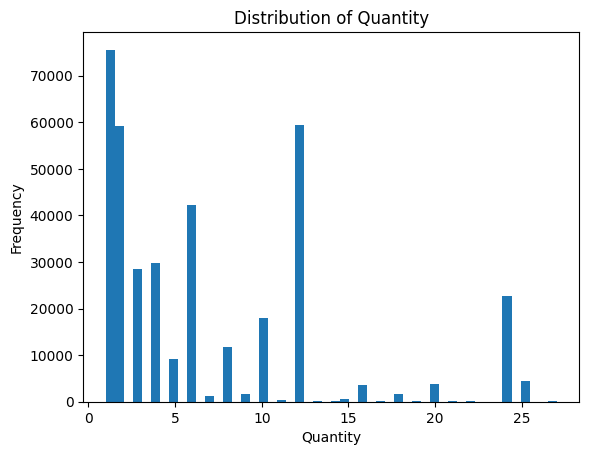

In [29]:
# Vẽ histogram để quan sát phân phối của Quantity
import matplotlib.pyplot as plt

plt.hist(df['Quantity'], bins=50)
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

Nhận xét: Phân phối của Quantity có dạng lệch phải, với phần lớn giao dịch tập trung ở mức thấp và một số ít giao dịch có giá trị rất cao.
Điều này cho thấy hành vi mua hàng phổ biến là mua với số lượng nhỏ, trong khi các đơn hàng lớn mang tính ngoại lệ.

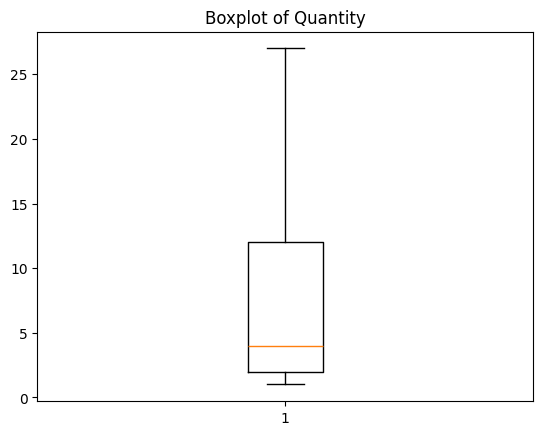

In [30]:
# Vẽ boxplot để phát hiện outliers
plt.boxplot(df['Quantity'])
plt.title('Boxplot of Quantity')
plt.show()

Nhận xét:

Boxplot cho thấy vẫn tồn tại một số outliers sau khi làm sạch, tuy nhiên mức độ không còn quá cực đoan.
Điều này cho thấy quá trình cleaning đã cải thiện chất lượng dữ liệu nhưng vẫn giữ lại các giá trị quan trọng có thể phản ánh hành vi mua hàng thực tế.

Dữ liệu ban đầu chứa nhiều vấn đề như giá trị thiếu, dữ liệu bất thường và outliers. Sau quá trình làm sạch, dữ liệu trở nên nhất quán và đáng tin cậy hơn.
Kết quả phân tích cho thấy doanh nghiệp phụ thuộc mạnh vào thị trường United Kingdom, trong khi các thị trường quốc tế khác vẫn chưa được khai thác đầy đủ.
Ngoài ra, doanh thu và số lượng bán có xu hướng tập trung vào một số sản phẩm chủ lực, và hành vi mua hàng chủ yếu là các đơn hàng nhỏ với một số ít giao dịch có giá trị lớn.



Biểu đồ doanh thu theo thời gian

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# Kiểm tra thử 5 dòng đầu
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.6,2009,12


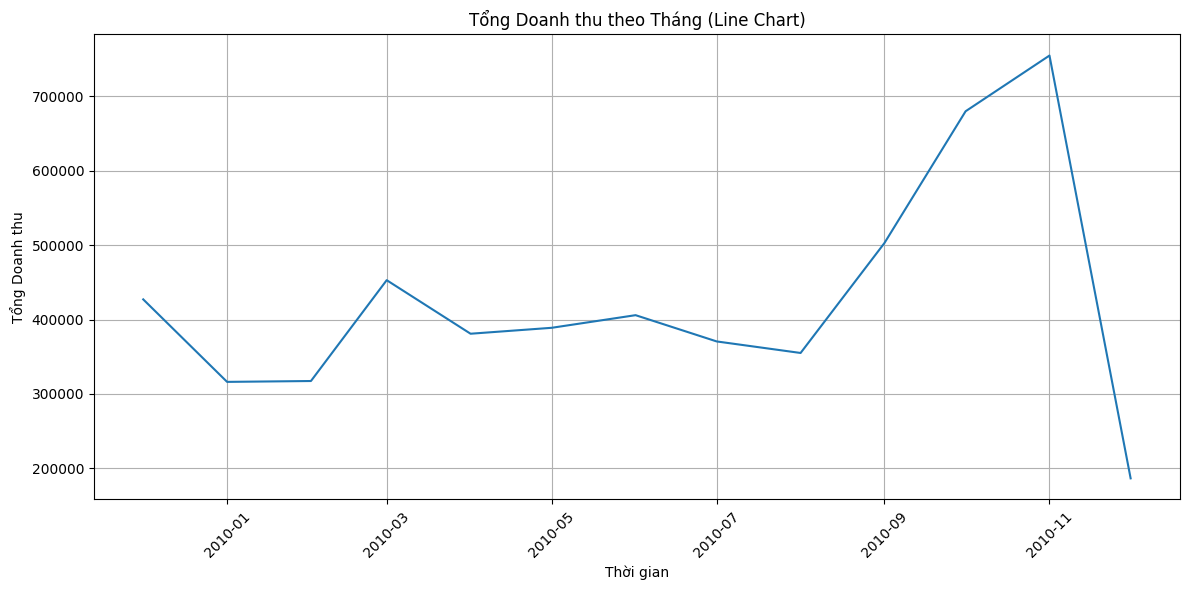

In [ ]:
# Chuyển đổi 'InvoiceDate' thành định dạng datetime nếu chưa được chuyển đổi
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Tạo cột 'YearMonth' để nhóm theo tháng
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

# Tính tổng doanh thu theo tháng
monthly_revenue = df.groupby('YearMonth')['Revenue'].sum().reset_index()

# Chuyển đổi 'YearMonth' về datetime để vẽ biểu đồ dễ dàng hơn
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
sns.lineplot(x='YearMonth', y='Revenue', data=monthly_revenue)
plt.title('Tổng Doanh thu theo Tháng (Line Chart)')
plt.xlabel('Thời gian')
plt.ylabel('Tổng Doanh thu')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Nhận xét:
Từ biểu đồ trên, chúng ta có thể thấy một số xu hướng về doanh thu:

Xu hướng tăng trưởng: Có vẻ như doanh thu có xu hướng tăng dần theo thời gian, đặc biệt là vào cuối năm 2010 và 2011.
Tính thời vụ: Doanh thu thường đạt đỉnh vào cuối mỗi năm (tháng 11 và 12), cho thấy tính thời vụ mạnh mẽ, có thể liên quan đến các dịp lễ hội hoặc mua sắm cuối năm.
Biến động: Có những biến động đáng kể giữa các tháng, nhưng xu hướng chung vẫn là tăng trưởng.

Top sản phẩm / quốc gia (Bar Chart)

/tmp/ipykernel_2628/295845481.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Revenue', y='Description', data=top_products, palette='viridis')


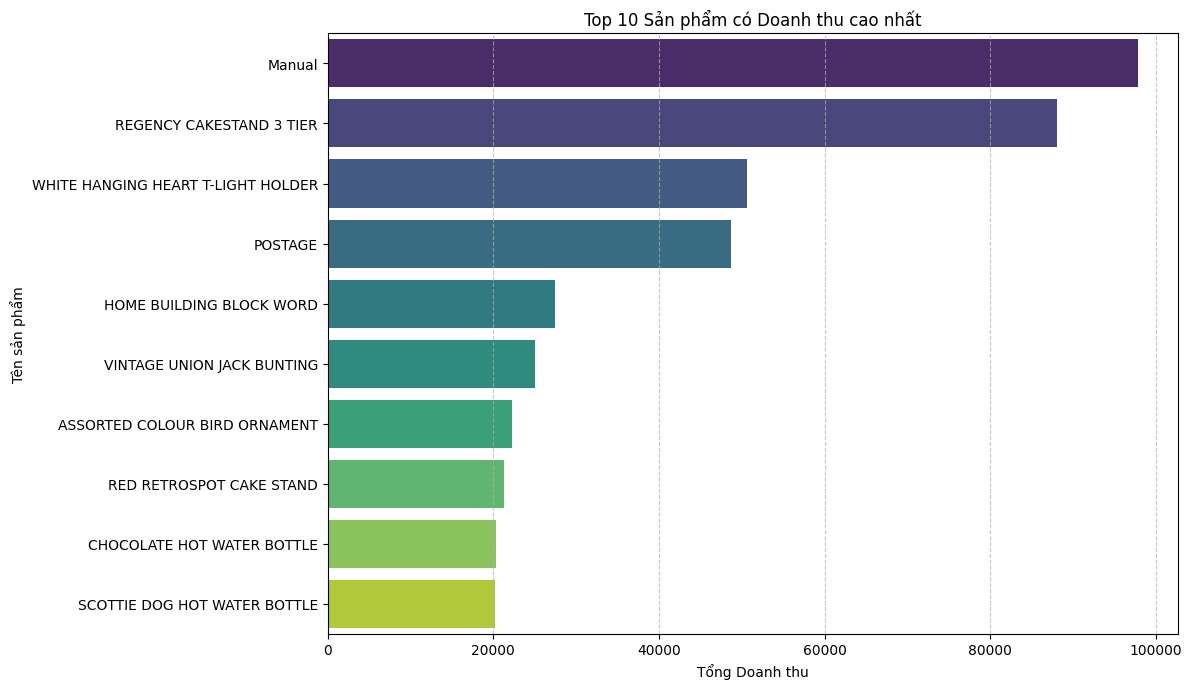

In [33]:
# Top 10 sản phẩm theo doanh thu
top_products = df.groupby('Description')['Revenue'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Revenue', y='Description', data=top_products, palette='viridis')
plt.title('Top 10 Sản phẩm có Doanh thu cao nhất')
plt.xlabel('Tổng Doanh thu')
plt.ylabel('Tên sản phẩm')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Nhận xét về Top 10 Sản phẩm có Doanh thu cao nhất:
Biểu đồ này hiển thị 10 sản phẩm đóng góp nhiều nhất vào tổng doanh thu. Từ đó, chúng ta có thể:

Xác định sản phẩm chủ lực: Các sản phẩm như 'Manual' và 'REGENCY CAKESTAND 3 TIER' có doanh thu vượt trội, cho thấy chúng là những mặt hàng bán chạy nhất hoặc có giá trị cao.
Chiến lược kinh doanh: Doanh nghiệp có thể tập trung vào việc duy trì chất lượng và đẩy mạnh tiếp thị cho các sản phẩm này, đồng thời nghiên cứu lý do thành công để áp dụng cho các sản phẩm khác.

/tmp/ipykernel_2628/939065880.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Revenue', y='Country', data=top_countries, palette='magma')


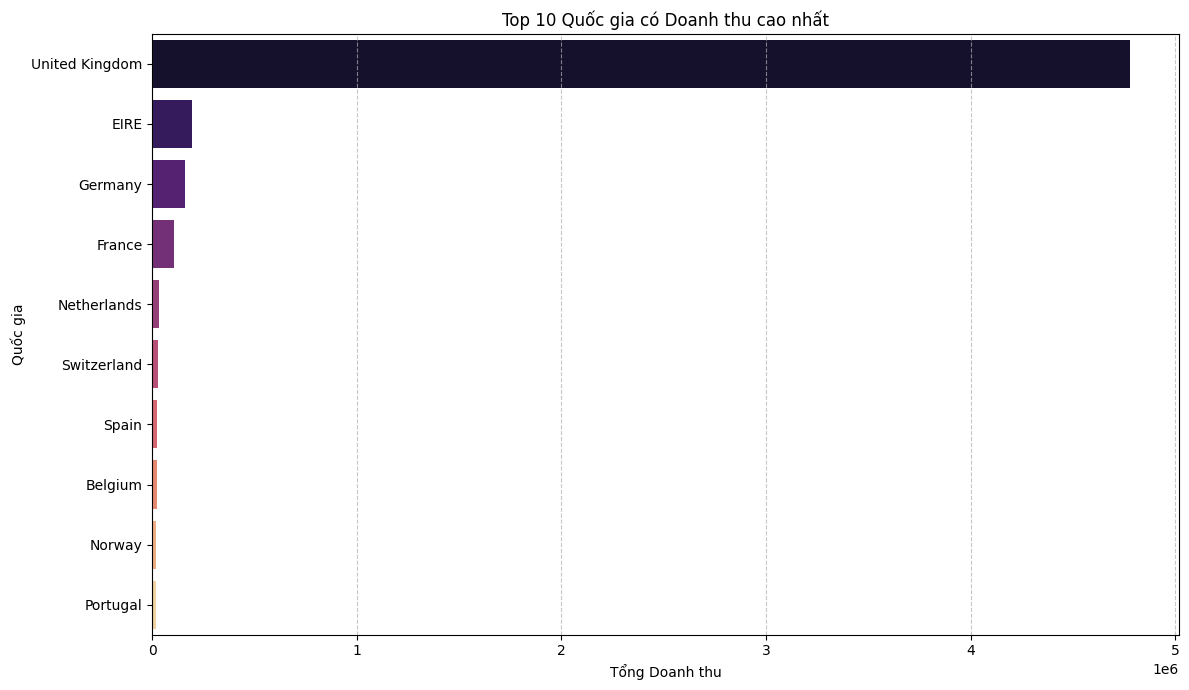

In [34]:
# Top 10 quốc gia theo doanh thu
top_countries = df.groupby('Country')['Revenue'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Revenue', y='Country', data=top_countries, palette='magma')
plt.title('Top 10 Quốc gia có Doanh thu cao nhất')
plt.xlabel('Tổng Doanh thu')
plt.ylabel('Quốc gia')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Nhận xét về Top 10 Quốc gia có Doanh thu cao nhất:
Biểu đồ này cho thấy các quốc gia đóng góp nhiều nhất vào doanh thu:

Thị trường trọng điểm: 'United Kingdom' chiếm phần lớn doanh thu, khẳng định đây là thị trường chính của doanh nghiệp. Các quốc gia khác như EIRE, Germany, France cũng đóng góp đáng kể.
Cơ hội mở rộng: Doanh nghiệp có thể xem xét các chiến lược đầu tư hoặc mở rộng thị phần tại các quốc gia có tiềm năng nhưng doanh thu chưa cao.

Phân bổ số lượng đơn hàng, giá trị đơn (Histogram, Boxplot)

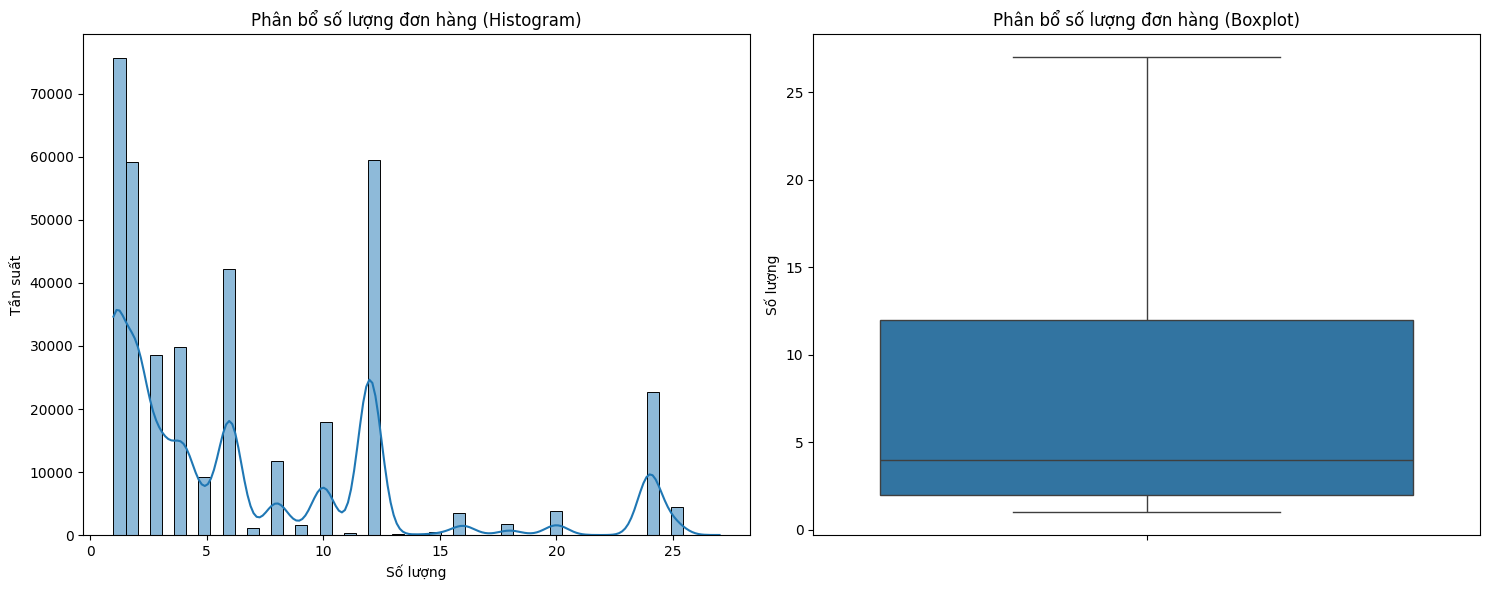

In [35]:
# Phân bổ số lượng đơn hàng (Quantity)
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # Histogram
sns.histplot(df['Quantity'], bins=50, kde=True)
plt.title('Phân bổ số lượng đơn hàng (Histogram)')
plt.xlabel('Số lượng')
plt.ylabel('Tần suất')

plt.subplot(1, 2, 2) # Boxplot
sns.boxplot(y=df['Quantity'])
plt.title('Phân bổ số lượng đơn hàng (Boxplot)')
plt.ylabel('Số lượng')

plt.tight_layout()
plt.show()

Nhận xét về Phân bổ số lượng đơn hàng (Quantity):    
Histogram: Biểu đồ histogram cho thấy phần lớn các đơn hàng có số lượng sản phẩm rất nhỏ, tập trung ở phía bên trái. Điều này ngụ ý rằng khách hàng thường mua số lượng ít sản phẩm trong một lần.   
Boxplot: Biểu đồ boxplot xác nhận rằng phần lớn dữ liệu Quantity nằm trong một phạm vi hẹp. Đồng thời, sự hiện diện của rất nhiều điểm ngoại lai (outliers) phía trên cho thấy có những đơn hàng với số lượng sản phẩm cực lớn, có thể là đơn hàng bán buôn hoặc đặt hàng đặc biệt.

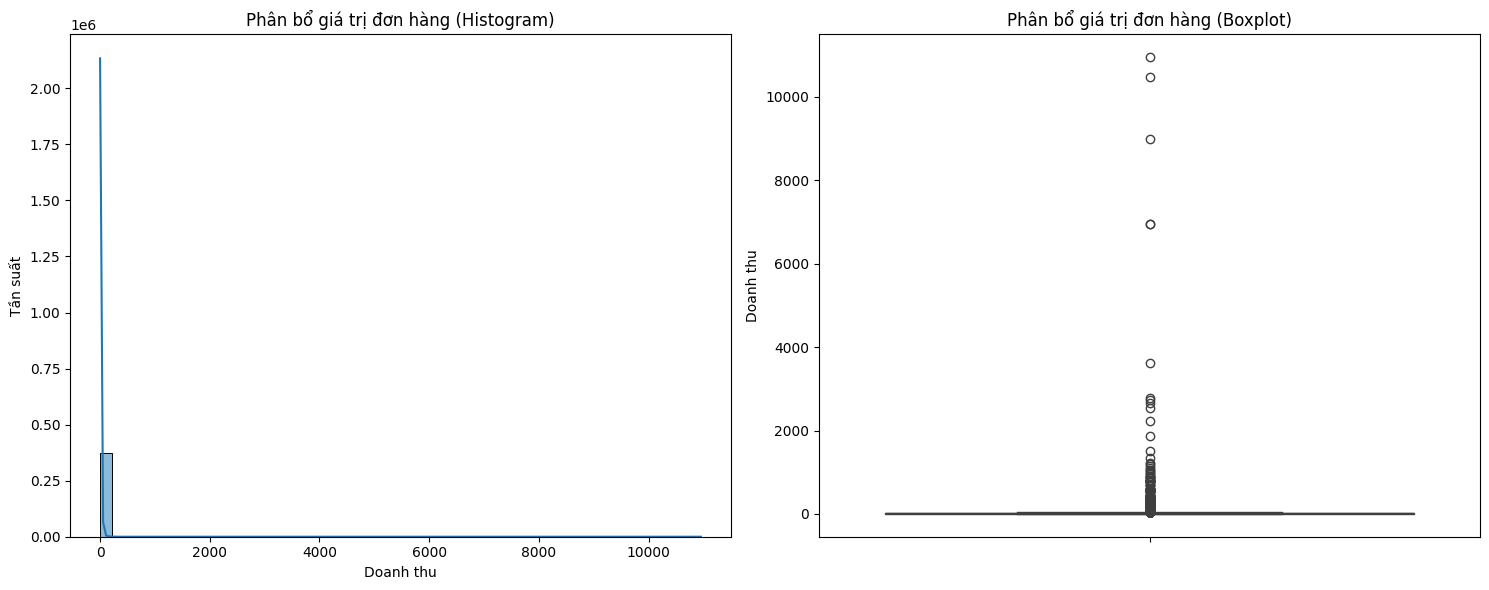

In [36]:
# Phân bổ giá trị đơn hàng (Revenue)
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # Histogram
sns.histplot(df['Revenue'], bins=50, kde=True)
plt.title('Phân bổ giá trị đơn hàng (Histogram)')
plt.xlabel('Doanh thu')
plt.ylabel('Tần suất')

plt.subplot(1, 2, 2) # Boxplot
sns.boxplot(y=df['Revenue'])
plt.title('Phân bổ giá trị đơn hàng (Boxplot)')
plt.ylabel('Doanh thu')

plt.tight_layout()
plt.show()

Nhận xét về Phân bổ giá trị đơn hàng (Revenue):    
Histogram: Tương tự như Quantity, biểu đồ histogram của Revenue cũng cho thấy phần lớn doanh thu đến từ các đơn hàng có giá trị nhỏ, tập trung ở mức thấp. Điều này phù hợp với việc khách hàng mua số lượng ít sản phẩm.   
Boxplot: Biểu đồ boxplot minh họa rõ ràng rằng phần lớn giá trị doanh thu nằm ở mức thấp, với một số lượng lớn các điểm ngoại lai có giá trị rất cao. Điều này chỉ ra rằng, mặc dù đa số đơn hàng có giá trị nhỏ, nhưng có một số ít đơn hàng có giá trị rất lớn, đóng góp đáng kể vào tổng doanh thu.

In [37]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [38]:
# Hiển thị 5 dòng đầu tiên của dataset
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.6,2009,12


In [39]:
# Hiển thị tên các cột trong dataset
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue', 'Year', 'Month'],
      dtype='object')


In [40]:
# Kiểm tra thông tin dataset sau khi clean
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 374622 entries, 0 to 525460
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      374622 non-null  object        
 1   StockCode    374622 non-null  object        
 2   Description  374622 non-null  object        
 3   Quantity     374622 non-null  int64         
 4   InvoiceDate  374622 non-null  datetime64[ns]
 5   Price        374622 non-null  float64       
 6   Customer ID  374622 non-null  float64       
 7   Country      374622 non-null  object        
 8   Revenue      374622 non-null  float64       
 9   Year         374622 non-null  int32         
 10  Month        374622 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(4)
memory usage: 31.4+ MB


In [41]:
# Chuyển cột InvoiceDate sang kiểu datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [42]:
# Kiểm tra thông tin dataset sau khi clean
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 374622 entries, 0 to 525460
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      374622 non-null  object        
 1   StockCode    374622 non-null  object        
 2   Description  374622 non-null  object        
 3   Quantity     374622 non-null  int64         
 4   InvoiceDate  374622 non-null  datetime64[ns]
 5   Price        374622 non-null  float64       
 6   Customer ID  374622 non-null  float64       
 7   Country      374622 non-null  object        
 8   Revenue      374622 non-null  float64       
 9   Year         374622 non-null  int32         
 10  Month        374622 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(4)
memory usage: 31.4+ MB


In [43]:
# Tạo snapshot date để tính Recency
df['TotalPrice'] = df['Quantity'] * df['Price']

In [44]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [45]:
print(snapshot_date)

2010-12-10 20:01:00


In [46]:
# Tính Recency, Frequency và Monetary cho từng khách hàng
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

In [47]:
# Đổi tên cột
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [48]:
# Hiển thị kết quả
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1262.42
12348.0,74,1,222.16
12349.0,43,3,2630.34
12351.0,11,1,300.93


In [49]:
# Chia Recency thành 4 nhóm điểm
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
# Chia Frequency thành 4 nhóm điểm
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
# Chia Monetary thành 4 nhóm điểm
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

In [50]:
# Kết hợp điểm RFM thành một mã phân loại khách hàng
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

print(rfm.head())

             Recency  Frequency  Monetary R_score F_score M_score RFM_Score
Customer ID                                                                
12346.0          165         11    372.86       1       4       2       142
12347.0            3          2   1262.42       4       2       3       423
12348.0           74          1    222.16       2       1       1       211
12349.0           43          3   2630.34       3       3       4       334
12351.0           11          1    300.93       4       1       2       412


In [51]:
# Hàm phân nhóm khách hàng

def customer_segment(row):
    if row['RFM_Score'] == '444':
        return 'Best Customers'
    elif row['R_score'] == 4:
        return 'Recent Customers'
    elif row['F_score'] == 4:
        return 'Loyal Customers'
    elif row['M_score'] == 4:
        return 'Big Spenders'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(customer_segment, axis=1)

print(rfm.head())

             Recency  Frequency  Monetary R_score F_score M_score RFM_Score  \
Customer ID                                                                   
12346.0          165         11    372.86       1       4       2       142   
12347.0            3          2   1262.42       4       2       3       423   
12348.0           74          1    222.16       2       1       1       211   
12349.0           43          3   2630.34       3       3       4       334   
12351.0           11          1    300.93       4       1       2       412   

                      Segment  
Customer ID                    
12346.0       Loyal Customers  
12347.0      Recent Customers  
12348.0                Others  
12349.0          Big Spenders  
12351.0      Recent Customers  


# **PHÂN KHÚC KHÁCH HÀNG**

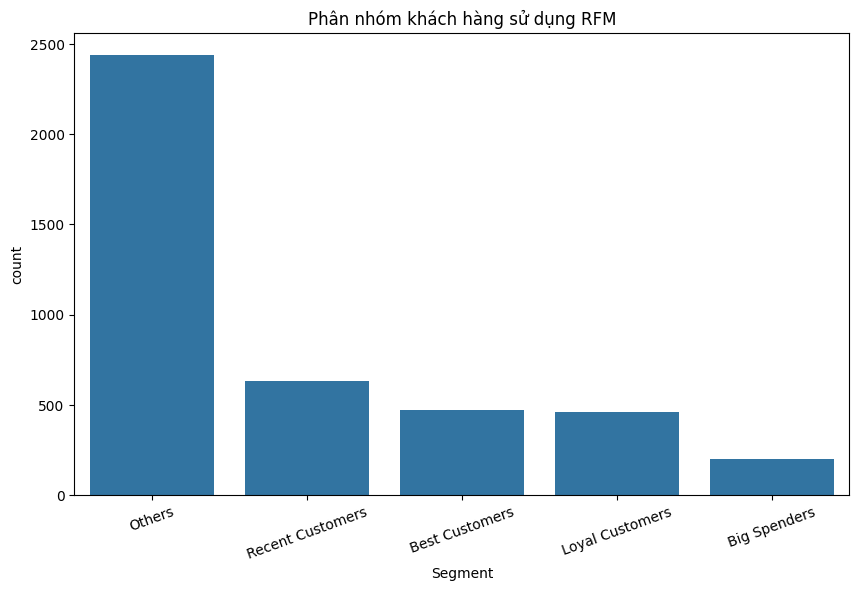

In [52]:
# Vẽ biểu đồ phân nhóm khách hàng theo RFM
plt.figure(figsize=(10,6))

sns.countplot(x='Segment', data=rfm,
              order=rfm['Segment'].value_counts().index)

plt.title('Phân nhóm khách hàng sử dụng RFM')
plt.xticks(rotation=20)
plt.show()

# **Nhận xét về Phân khúc khách hàng bằng mô hình RFM (Recency - Frequency - Monetary):**

Biểu đồ phân khúc khách hàng theo mô hình RFM cho thấy số lượng khách hàng tập trung chủ yếu ở nhóm Others, trong khi các nhóm khách hàng có giá trị cao như Best Customers, Loyal Customers và Big Spenders chiếm tỷ lệ thấp hơn.

Từ kết quả này, có thể rút ra một số insight quan trọng như:

***Nhóm Others chiếm tỷ lệ lớn nhất:*** Điều này cho thấy phần lớn khách hàng hiện tại chưa có mức độ tương tác hoặc giá trị mua hàng cao. Đây có thể là nhóm khách hàng mua ít, không thường xuyên hoặc có mức chi tiêu thấp.

***Best Customers và Loyal Customers có số lượng ít hơn nhưng quan trọng:*** Mặc dù số lượng không nhiều, đây là nhóm khách hàng mang lại giá trị doanh thu lớn và có khả năng đóng góp đáng kể vào lợi nhuận doanh nghiệp. Nhóm này cần được ưu tiên chăm sóc và giữ chân.

***Big Spenders có số lượng thấp nhất:*** Điều này cho thấy chỉ có một phần nhỏ khách hàng có mức chi tiêu rất cao. Doanh nghiệp có thể triển khai các chương trình cá nhân hóa hoặc ưu đãi VIP để tăng trải nghiệm cho nhóm khách hàng này.

***Recent Customers có tiềm năng phát triển:*** Đây là nhóm khách hàng mới tương tác gần đây và có khả năng trở thành khách hàng trung thành nếu được chăm sóc phù hợp.

# **Ý nghĩa kinh doanh:**

Kết quả phân tích RFM giúp doanh nghiệp hiểu rõ giá trị của từng nhóm khách hàng để xây dựng chiến lược marketing phù hợp. Doanh nghiệp có thể:

***Tập trung giữ chân nhóm khách hàng giá trị cao***

***Tăng cường loyalty program cho khách hàng trung thành***

***Thực hiện chiến dịch re-engagement cho nhóm Others***

***Cá nhân hóa ưu đãi nhằm tăng giá trị vòng đời khách hàng (Customer Lifetime Value)***

# **TOP KHÁCH HÀNG CÓ MỨC CHI TIÊU CAO NHẤT**

In [53]:
# Tìm 10 khách hàng có mức chi tiêu cao nhất
top_customers = (
    rfm.sort_values(
        by='Monetary',
        ascending=False
    )
    .head(10)
)

print(top_customers)

             Recency  Frequency   Monetary R_score F_score M_score RFM_Score  \
Customer ID                                                                    
14911.0            1        205  129898.30       4       4       4       444   
14156.0           14         83   57667.02       4       4       4       444   
17850.0            8        155   50623.87       4       4       4       444   
13089.0            4         89   35682.65       4       4       4       444   
15311.0            1        116   29452.50       4       4       4       444   
17841.0            1         90   27560.94       4       4       4       444   
13081.0            7         18   23516.42       4       4       4       444   
13093.0            9         45   22928.47       4       4       4       444   
14298.0           11         34   22073.38       4       4       4       444   
14646.0           10         59   19276.98       4       4       4       444   

                    Segment  
Customer 

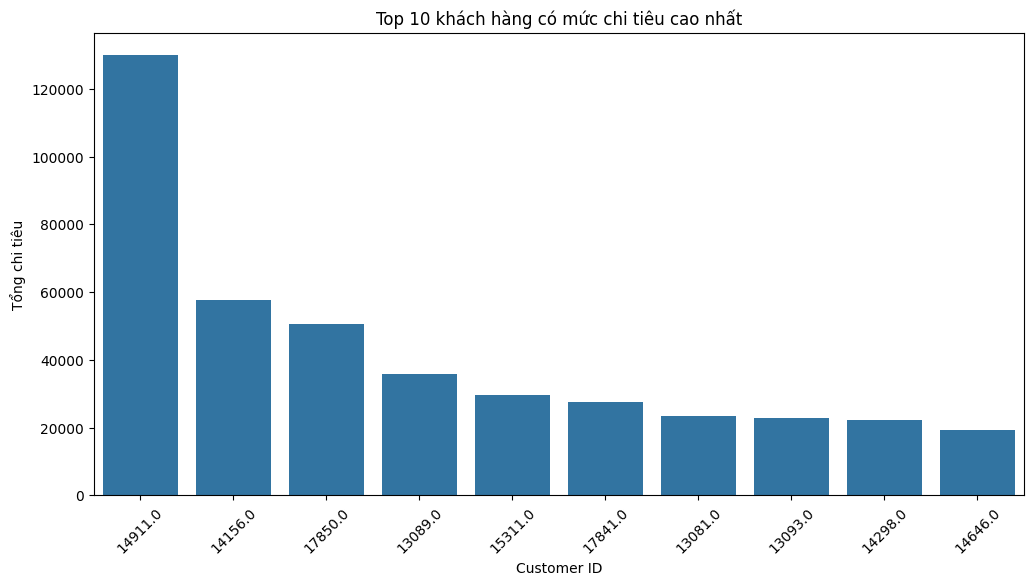

In [54]:
# Vẽ biểu đồ top 10 khách hàng có mức chi tiêu cao nhất
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.index.astype(str),
    y=top_customers['Monetary']
)

plt.title('Top 10 khách hàng có mức chi tiêu cao nhất')

plt.xlabel('Customer ID')
plt.ylabel('Tổng chi tiêu')

plt.xticks(rotation=45)

plt.show()

# **1. Sự xuất hiện của "Siêu khách hàng" (Outlier)**
***Khách hàng ID 14911:*** Đây là cá nhân nổi bật nhất với mức chi tiêu vượt xa phần còn lại, đạt hơn 120,000.

Mức chi tiêu của khách hàng này gấp hơn 2 lần người đứng thứ hai và gấp khoảng 6 lần người đứng thứ mười. Đây chính là đối tượng "Whale" (khách hàng cá voi) cực kỳ quan trọng đối với doanh thu của công ty.

# **2. Phân nhóm chi tiêu**
Dựa vào biểu đồ, có thể chia 10 khách hàng này thành 3 nhóm:

***Nhóm dẫn đầu (Top 1)***: ID 14911 (Chi tiêu > 120,000).

***Nhóm tiềm năng cao (Top 2-3)***: ID 14156 và ID 17850. Hai khách hàng này có mức chi tiêu khá cao, dao động từ 50,000 đến 60,000.

***Nhóm ổn định (Top 4-10)***: Các khách hàng còn lại có mức chi tiêu giảm dần khá đều, từ khoảng 40,000 xuống 20,000. Khoảng cách giữa các vị trí trong nhóm này không quá lớn, cho thấy sự cạnh tranh sát sao.

# **3. Ý nghĩa đối với doanh nghiệp (Nguyên lý Pareto)**
***Biểu đồ này minh họa rất rõ nguyên lý 80/20:*** Một nhóm rất nhỏ khách hàng đang đóng góp một tỷ trọng doanh thu rất lớn.

***Chỉ cần giữ chân được 3 khách hàng đầu tiên (14911, 14156, 17850)***, doanh nghiệp đã bảo vệ được một phần lớn nguồn thu từ nhóm khách hàng VIP.

# **4. Gợi ý chiến lược hành động**
***Chương trình khách hàng thân thiết (Loyalty Program):***

Đối với ID 14911, cần có chế độ chăm sóc đặc biệt (quà tặng riêng, ưu tiên hỗ trợ, hoặc người quản lý tài khoản riêng) để đảm bảo họ không rời bỏ thương hiệu.

Với nhóm từ Top 4-10, có thể đưa ra các ưu đãi nâng cấp hạng thành viên để khuyến khích họ chi tiêu nhiều hơn nhằm tiến lên nhóm trên.

***Phân tích hành vi:***

Bạn nên kiểm tra xem những khách hàng này thường mua gì. Ví dụ: Khách hàng 14911 có phải là người mua sỉ (B2B) không, hay là khách hàng cá nhân có sức mua lớn?

Nếu họ mua các sản phẩm ở biểu đồ trước (như Regency Cakestand hay các dịch vụ Manual), doanh nghiệp có thể giới thiệu các sản phẩm tương tự trực tiếp cho họ.

***Kiểm tra tần suất:***

Cần xem thêm chỉ số về tần suất mua hàng (Frequency) để biết khách hàng 14911 chi đậm một lần hay mua hàng đều đặn mỗi tháng.

# **DOANH THU THEO THÁNG**

In [55]:

top_customers = rfm.sort_values(
    by='Monetary',
    ascending=False
).head(10)

top_customers

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
Customer ID,,,,,,,,
14911.0,1,205,129898.30,4,4,4,444,Best Customers
14156.0,14,83,57667.02,4,4,4,444,Best Customers
17850.0,8,155,50623.87,4,4,4,444,Best Customers
13089.0,4,89,35682.65,4,4,4,444,Best Customers
15311.0,1,116,29452.50,4,4,4,444,Best Customers
17841.0,1,90,27560.94,4,4,4,444,Best Customers
13081.0,7,18,23516.42,4,4,4,444,Best Customers
13093.0,9,45,22928.47,4,4,4,444,Best Customers
14298.0,11,34,22073.38,4,4,4,444,Best Customers


In [56]:
# Tính tổng doanh thu theo tháng
df['Month'] = df['InvoiceDate'].dt.month
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

print(monthly_sales)

Month
1     316184.272
2     317346.906
3     452915.531
4     380919.692
5     388890.540
6     405865.260
7     370542.240
8     355046.090
9     502874.281
10    679995.290
11    754883.052
12    613599.610
Name: TotalPrice, dtype: float64


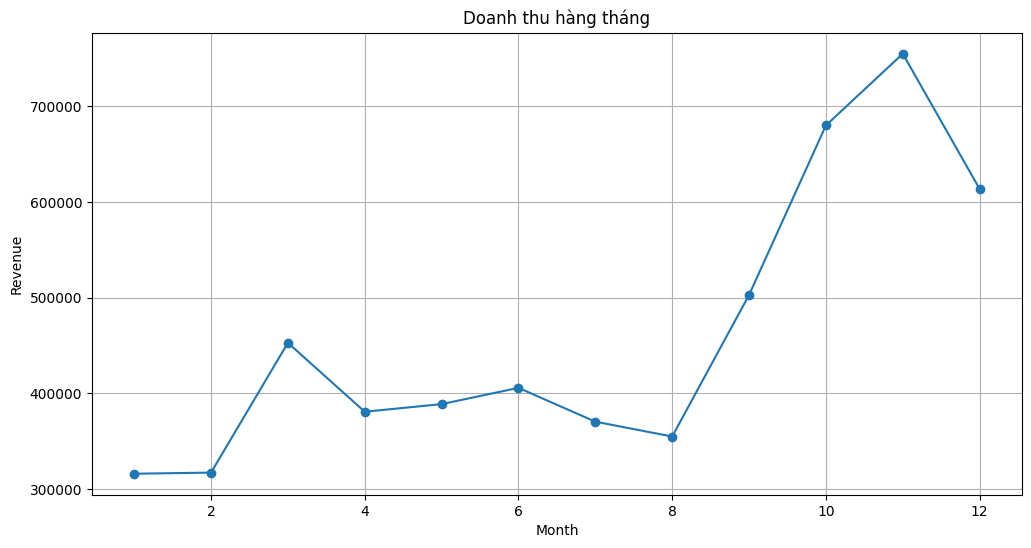

In [57]:
# Vẽ biểu đồ doanh thu theo tháng
plt.figure(figsize=(12,6))

monthly_sales.plot(marker='o')

plt.title('Doanh thu hàng tháng')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)

plt.show()

# **Nhận xét về Doanh thu hàng tháng:**

Biểu đồ doanh thu hàng tháng cho thấy doanh thu có sự biến động rõ rệt theo từng thời điểm trong năm. Từ kết quả phân tích, có thể nhận thấy một số xu hướng quan trọng như sau:

***Doanh thu thấp ở đầu năm:*** Trong các tháng 1 và 2, doanh thu ở mức thấp và khá ổn định. Điều này cho thấy nhu cầu mua sắm của khách hàng trong giai đoạn đầu năm chưa cao.

***Tăng trưởng vào tháng 3:*** Doanh thu tăng mạnh vào tháng 3, cho thấy có thể xuất hiện nhu cầu mua sắm cao hơn hoặc tác động từ các chiến dịch marketing, chương trình khuyến mãi hoặc yếu tố mùa vụ.

***Giai đoạn giữa năm tương đối ổn định:*** Từ tháng 4 đến tháng 8, doanh thu dao động ở mức trung bình và không có biến động quá lớn. Điều này phản ánh thị trường duy trì trạng thái ổn định trong giai đoạn này.

***Tăng trưởng mạnh vào cuối năm:*** Từ tháng 9 đến tháng 11, doanh thu tăng mạnh liên tục và đạt đỉnh vào tháng 11. Đây là dấu hiệu rõ rệt của seasonal shopping behavior, có thể liên quan đến các dịp lễ hội, mùa mua sắm cuối năm hoặc các chương trình giảm giá lớn.

***Giảm nhẹ vào tháng 12:*** Sau khi đạt đỉnh ở tháng 11, doanh thu giảm nhẹ trong tháng 12 nhưng vẫn duy trì ở mức cao hơn nhiều so với phần lớn các tháng còn lại trong năm.

# **Ý nghĩa kinh doanh:**

Kết quả phân tích cho thấy doanh thu có xu hướng tăng mạnh vào cuối năm. Doanh nghiệp có thể tận dụng insight này để:

***Tăng cường chiến dịch marketing trong giai đoạn cuối năm***

***Chuẩn bị inventory và logistics trước mùa cao điểm***

***Triển khai chương trình khuyến mãi vào các tháng có nhu cầu cao***

***Tối ưu nguồn lực nhằm đáp ứng lượng đơn hàng tăng mạnh***

# **DOANH THU THEO MÙA**

In [58]:
#Tính tổng doanh thu theo mùa
def get_season(month):
    if month in [12, 1, 2]:
        return 'Đông'
    elif month in [3, 4, 5]:
        return 'Xuân'
    elif month in [6, 7, 8]:
        return 'Hạ'
    else:
        return 'Thu'

df['Season'] = df['Month'].apply(get_season)

In [59]:
season_sales = df.groupby('Season')['TotalPrice'].sum()

print(season_sales)

Season
Hạ      1131453.590
Thu     1937752.623
Xuân    1222725.763
Đông    1247130.788
Name: TotalPrice, dtype: float64


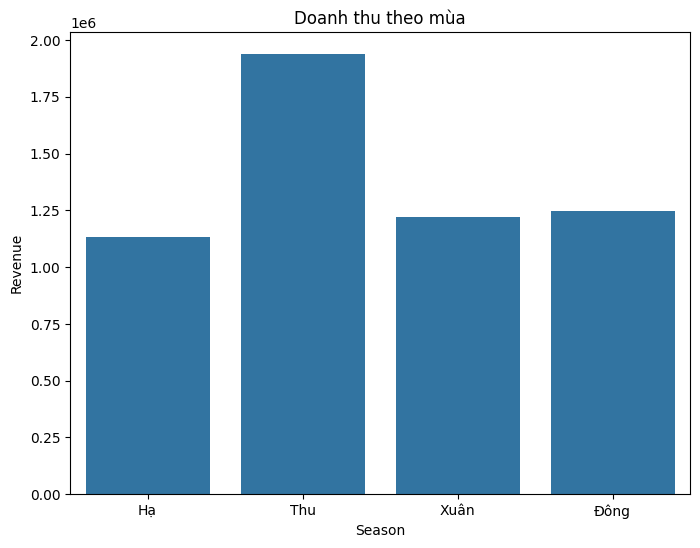

In [60]:
# Vẽ minh họa tổng doanh thu theo mùa
plt.figure(figsize=(8,6))

sns.barplot(
    x=season_sales.index,
    y=season_sales.values
)

plt.title('Doanh thu theo mùa')
plt.xlabel('Season')
plt.ylabel('Revenue')

plt.show()

Biểu đồ cho thấy doanh thu mùa Thu cao nhất và vượt trội rõ rệt so với các mùa còn lại, trong khi mùa Hạ thấp nhất. Hai mùa Xuân và Đông có doanh thu khá gần nhau, nằm ở mức trung bình.

# **Nhận xét cụ thể**
***Mùa Thu đạt khoảng 1,9 triệu, cao nhất trong 4 mùa.***

***Mùa Hạ chỉ khoảng 1,1 triệu, thấp nhất.***

***Mùa Xuân và mùa Đông đều quanh mức 1,2–1,25 triệu, chênh lệch không đáng kể***.

***Mức chênh lệch giữa mùa cao nhất và thấp nhất là khá lớn, cho thấy doanh thu có tính mùa vụ rõ rệt.***

# **Ý nghĩa**
***Doanh nghiệp có thể đang bán tốt hơn vào mùa Thu, có thể do nhu cầu tăng theo thời tiết, lễ hội, hoặc hành vi mua sắm theo mùa.***

***Mùa Hạ có thể là giai đoạn cần tăng khuyến mãi, tối ưu quảng cáo hoặc ra sản phẩm phù hợp hơn để cải thiện doanh thu.***

***Nếu đây là dữ liệu bán hàng theo năm, nên kết hợp thêm số liệu theo tháng để xác định chính xác nguyên nhân biến động.***

# ***Tổng kết và Đề xuất***
# **Tổng kết**

Qua quá trình phân tích dữ liệu bán hàng bằng mô hình RFM và phân tích xu hướng doanh thu theo thời gian, nhóm đã xác định được hành vi mua sắm và giá trị của từng nhóm khách hàng.

Kết quả phân tích RFM cho thấy phần lớn khách hàng thuộc nhóm ***“Others”***, trong khi các nhóm khách hàng có giá trị cao như ***“Best Customers”*** và ***“Loyal Customers”*** chiếm tỷ lệ nhỏ hơn nhưng đóng vai trò quan trọng đối với doanh thu doanh nghiệp.

Ngoài ra, phân tích doanh thu theo tháng cho thấy doanh thu có xu hướng tăng mạnh vào giai đoạn cuối năm, đặc biệt từ tháng 9 đến tháng 11. Điều này phản ánh ảnh hưởng của yếu tố mùa vụ và nhu cầu mua sắm tăng cao trong các dịp lễ hội hoặc mùa khuyến mãi.

Nhìn chung, việc ứng dụng Business Analytics giúp doanh nghiệp:

***Hiểu rõ hành vi khách hàng***

***Phân nhóm khách hàng hiệu quả***

***Hỗ trợ ra quyết định dựa trên dữ liệu***

***Tối ưu chiến lược marketing và bán hàng***

# **Đề xuất**

Dựa trên kết quả phân tích, nhóm đề xuất một số giải pháp nhằm nâng cao hiệu quả kinh doanh như sau:

***Tăng cường chăm sóc khách hàng giá trị cao:*** Doanh nghiệp nên triển khai loyalty program, ưu đãi cá nhân hóa và các chương trình membership dành cho nhóm Best Customers và Loyal Customers nhằm tăng khả năng giữ chân khách hàng.

***Thực hiện chiến dịch re-engagement:*** Đối với nhóm khách hàng thuộc “Others”, doanh nghiệp có thể áp dụng email marketing, voucher giảm giá hoặc remarketing để tăng khả năng quay lại mua hàng.

***Tối ưu hoạt động kinh doanh theo mùa:*** Doanh nghiệp nên tập trung nguồn lực, inventory và chiến dịch marketing vào giai đoạn cuối năm khi nhu cầu mua sắm tăng mạnh.

***Ứng dụng phân tích dữ liệu nâng cao:*** Trong tương lai, doanh nghiệp có thể áp dụng Machine Learning hoặc Customer Lifetime Value (CLV) để dự đoán hành vi khách hàng và tối ưu chiến lược kinh doanh hiệu quả hơn.